# Phase 1: Network Flow Analysis with Sliding Windows
## Dataset-Agnostic Approach for Zeek/CICIDS/NetFlow

This notebook:
1. Loads your network traffic data
2. Cleans and preprocesses it
3. Extracts sliding window features (10s, 1min, 5min, 15min, 1hr)
4. Prepares data for ML/anomaly detection

---
## PART 1: Setup & Library Installation

In [ ]:
# Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


---
## PART 2: Sliding Window Feature Extraction Library
This is the core engine that handles all window operations

In [ ]:
# ============================================================
# SLIDING WINDOW FEATURE EXTRACTION ENGINE
# ============================================================

WINDOW_SIZES = {
    "10s":  pd.Timedelta("10s"),
    "1min": pd.Timedelta("1min"),
    "5min": pd.Timedelta("5min"),
    "15min": pd.Timedelta("15min"),
    "1hr":  pd.Timedelta("1hr"),
}

# Schema mappings for different datasets
SCHEMA_ADAPTERS = {
    "zeek": {
        "ts": "timestamp", "id.orig_h": "src_ip", "id.resp_h": "dst_ip",
        "id.orig_p": "src_port", "id.resp_p": "dst_port", "proto": "protocol",
        "duration": "duration", "orig_bytes": "orig_bytes",
        "resp_bytes": "dst_bytes", "conn_state": "conn_state",
    },
    "cicids": {
        "Timestamp": "timestamp", "Source IP": "src_ip", "Destination IP": "dst_ip",
        "Source Port": "src_port", "Destination Port": "dst_port", "Protocol": "protocol",
        "Flow Duration": "duration", "Total Fwd Packets": "orig_bytes",
        "Total Backward Packets": "dst_bytes", "Label": "label",
    },
    "netflow": {
        "te": "timestamp", "sa": "src_ip", "da": "dst_ip", "sp": "src_port",
        "dp": "dst_port", "pr": "protocol", "td": "duration",
        "ibyt": "orig_bytes", "obyt": "dst_bytes", "lbl": "label",
    },
    "universal": None,
}


def detect_schema(df):
    """Auto-detect dataset format."""
    cols = set(df.columns)
    if "id.orig_h" in cols: return "zeek"
    if "Source IP" in cols and "Flow Duration" in cols: return "cicids"
    if "sa" in cols and "ibyt" in cols: return "netflow"
    if "src_ip" in cols and "timestamp" in cols: return "universal"
    raise ValueError(f"Unknown schema: {list(cols)[:10]}")


def normalize_schema(df, schema="auto"):
    """Convert to universal column names."""
    if schema == "auto":
        schema = detect_schema(df)
        print(f"[Schema] Detected: {schema}")

    mapping = SCHEMA_ADAPTERS.get(schema)
    if mapping:
        df = df.rename(columns={k: v for k, v in mapping.items() if k in df.columns})
    return df


def prepare_timestamps(df):
    """Convert timestamp column to datetime."""
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        if pd.api.types.is_float_dtype(df["timestamp"]):
            df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
        else:
            df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df.sort_values("timestamp").reset_index(drop=True)


def aggregate_window(window_df):
    """Extract features from a single window."""
    feats = {}
    n = len(window_df)
    feats["conn_count"] = n

    if n == 0:
        return feats

    cols = set(window_df.columns)

    # Volume features
    if "orig_bytes" in cols:
        ob = pd.to_numeric(window_df["orig_bytes"], errors="coerce").fillna(0)
        feats["orig_bytes_sum"] = ob.sum()
        feats["orig_bytes_mean"] = ob.mean()
        feats["orig_bytes_std"] = ob.std(ddof=0)

    if "dst_bytes" in cols:
        db = pd.to_numeric(window_df["dst_bytes"], errors="coerce").fillna(0)
        feats["dst_bytes_sum"] = db.sum()
        feats["dst_bytes_mean"] = db.mean()
        feats["dst_bytes_std"] = db.std(ddof=0)

    if "orig_bytes" in cols and "dst_bytes" in cols:
        feats["bytes_ratio"] = feats.get("orig_bytes_sum", 0) / (feats.get("dst_bytes_sum", 0) + 1e-9)

    # Duration features
    if "duration" in cols:
        dur = pd.to_numeric(window_df["duration"], errors="coerce").fillna(0)
        feats["duration_mean"] = dur.mean()
        feats["duration_max"] = dur.max()
        feats["duration_std"] = dur.std(ddof=0)

    # Diversity features
    if "src_ip" in cols:
        feats["unique_src_ips"] = window_df["src_ip"].nunique()
    if "dst_ip" in cols:
        feats["unique_dst_ips"] = window_df["dst_ip"].nunique()
    if "dst_port" in cols:
        feats["unique_dst_ports"] = window_df["dst_port"].nunique()
    if "src_port" in cols:
        feats["unique_src_ports"] = window_df["src_port"].nunique()

    # Connection state features
    if "conn_state" in cols:
        feats["unique_conn_states"] = window_df["conn_state"].nunique()
        failed = window_df["conn_state"].isin(["REJ", "RSTO", "RSTOS0", "S0"])
        feats["failed_conn_ratio"] = failed.sum() / n

    # Protocol distribution
    if "protocol" in cols:
        proto = window_df["protocol"].str.lower().value_counts(normalize=True)
        for p in ["tcp", "udp", "icmp"]:
            feats[f"proto_ratio_{p}"] = proto.get(p, 0.0)

    # Fan-out (lateral movement signal)
    if "src_ip" in cols and "dst_ip" in cols and n > 0:
        top_src = window_df["src_ip"].value_counts().idxmax()
        feats["top_src_fanout"] = window_df[window_df["src_ip"] == top_src]["dst_ip"].nunique()

    # Inter-arrival time
    if "timestamp" in cols and n > 1:
        ts = window_df["timestamp"].sort_values()
        iat = ts.diff().dt.total_seconds().dropna()
        if len(iat) > 0:
            feats["iat_mean"] = iat.mean()
            feats["iat_std"] = iat.std(ddof=0)
            feats["iat_min"] = iat.min()

    return feats


def build_sliding_windows(df, window_label, window_size, step_size=None, label_col="label"):
    """Create sliding windows and extract features."""
    if step_size is None:
        step_size = window_size / 2

    t_start = df["timestamp"].min()
    t_end = df["timestamp"].max()
    records = []
    current = t_start

    while current + window_size <= t_end + step_size:
        window_end = current + window_size
        mask = (df["timestamp"] >= current) & (df["timestamp"] < window_end)
        window_df = df[mask]

        feats = aggregate_window(window_df)
        feats["window"] = window_label
        feats["window_start"] = current
        feats["window_end"] = window_end

        if label_col in df.columns and len(window_df) > 0:
            feats["label"] = window_df[label_col].mode()[0] if len(window_df[label_col].mode()) > 0 else "unknown"

        records.append(feats)
        current += step_size

    return pd.DataFrame(records)


def build_all_windows(df, schema="auto", label_col="label", step_fraction=0.5):
    """Full pipeline: normalize → extract all window sizes."""
    print("[1/3] Normalizing schema...")
    df = normalize_schema(df, schema=schema)

    print("[2/3] Preparing timestamps...")
    df = prepare_timestamps(df)

    print(f"[3/3] Building windows over {len(df):,} rows")
    print(f"      Time range: {df['timestamp'].min()} → {df['timestamp'].max()}")

    all_windows = {}
    for label, size in WINDOW_SIZES.items():
        step = size * step_fraction
        result = build_sliding_windows(df, label, size, step, label_col)
        all_windows[label] = result
        print(f"      ✓ {label:6} → {len(result):6,} windows, {len(result.columns):2} features")

    return all_windows


def merge_all_windows(all_windows):
    """Combine all window scales into one dataset."""
    combined = pd.concat(list(all_windows.values()), ignore_index=True)
    combined = pd.get_dummies(combined, columns=["window"], prefix="scale")
    return combined


print("✓ Sliding window engine loaded")

✓ Sliding window engine loaded


---
## PART 3: Load Your Data
Replace this with your actual data loading code

In [ ]:
# Define column names (Zeek format from your screenshot)
conn_columns = [
    "ts", "uid", "id.orig_h", "id.orig_p", "id.resp_h", "id.resp_p",
    "proto", "service", "duration", "orig_bytes", "resp_bytes",
    "conn_state", "local_orig", "local_resp", "missed_bytes",
    "history", "orig_pkts", "orig_ip_bytes", "resp_pkts",
    "resp_ip_bytes", "tunnel_parents"
]

# Load your data - MODIFY THIS PATH
df = pd.read_csv("/content/sample_data/conn.csv", sep="\t", header=None, names=conn_columns, comment="#")

# For demo/testing, create sample data
print("Creating sample data for demonstration...")
np.random.seed(42)
n_samples = 10000

df = pd.DataFrame({
    "ts": pd.date_range("2024-01-01", periods=n_samples, freq="1s").astype(np.int64) / 10**9,
    "id.orig_h": np.random.choice([f"192.168.1.{i}" for i in range(1, 20)], n_samples),
    "id.resp_h": np.random.choice([f"10.0.0.{i}" for i in range(1, 50)], n_samples),
    "id.orig_p": np.random.randint(1024, 65535, n_samples),
    "id.resp_p": np.random.choice([22, 80, 443, 3389, 8080], n_samples),
    "proto": np.random.choice(["tcp", "udp", "icmp"], n_samples, p=[0.7, 0.25, 0.05]),
    "duration": np.random.exponential(5, n_samples),
    "orig_bytes": np.random.randint(100, 100000, n_samples),
    "resp_bytes": np.random.randint(100, 100000, n_samples),
    "conn_state": np.random.choice(["SF", "S0", "REJ", "RSTO"], n_samples, p=[0.8, 0.1, 0.05, 0.05]),
})

# Add labels (if you have ground truth)
df["label"] = "benign"  # Replace with actual labels if available

print(f"Loaded {len(df):,} connections")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Creating sample data for demonstration...
Loaded 10,000 connections
Columns: ['ts', 'id.orig_h', 'id.resp_h', 'id.orig_p', 'id.resp_p', 'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'label']

First few rows:


,ts,id.orig_h,id.resp_h,id.orig_p,id.resp_p,proto,duration,orig_bytes,resp_bytes,conn_state,label
0,1.704067e+09,192.168.1.7,10.0.0.22,23790,3389,tcp,2.137853,68657,31214,REJ,benign
1,1.704067e+09,192.168.1.15,10.0.0.24,30761,8080,tcp,0.929330,52322,20675,RSTO,benign
2,1.704067e+09,192.168.1.11,10.0.0.17,22237,3389,udp,1.271569,75356,27675,S0,benign
3,1.704067e+09,192.168.1.8,10.0.0.21,29379,443,tcp,0.031711,76667,82435,SF,benign
4,1.704067e+09,192.168.1.7,10.0.0.11,63263,443,tcp,5.596327,12670,29366,SF,benign


---
## PART 4: Data Cleaning
Your existing preprocessing code

In [ ]:
# Remove null values
print("Before cleaning:", len(df))
df = df[df["id.orig_h"].notna()]
df = df[df["ts"].notna()]
print("After cleaning:", len(df))

# Handle missing bytes
df["orig_bytes"] = df["orig_bytes"].fillna(0)
df["resp_bytes"] = df["resp_bytes"].fillna(0)
df["duration"] = df["duration"].fillna(0)

print("\n✓ Data cleaned")

Before cleaning: 10000
After cleaning: 10000

✓ Data cleaned


---
## PART 5: Extract Sliding Window Features
**THIS IS THE MAIN STEP**

In [ ]:
# Extract all window sizes
print("\n" + "="*60)
print("EXTRACTING SLIDING WINDOW FEATURES")
print("="*60 + "\n")

windows = build_all_windows(
    df,
    schema="zeek",        # or "auto" for auto-detection
    label_col="label",    # column with labels (if available)
    step_fraction=0.5     # 50% overlap between windows
)

# Access individual window dataframes
df_10s = windows["10s"]
df_1min = windows["1min"]
df_5min = windows["5min"]
df_15min = windows["15min"]
df_1hr = windows["1hr"]

print("\n" + "="*60)
print("RESULTS:")
print("="*60)
print(f"10s windows:   {df_10s.shape}")
print(f"1min windows:  {df_1min.shape}")
print(f"5min windows:  {df_5min.shape}")
print(f"15min windows: {df_15min.shape}")
print(f"1hr windows:   {df_1hr.shape}")


EXTRACTING SLIDING WINDOW FEATURES

[1/3] Normalizing schema...
[2/3] Preparing timestamps...
[3/3] Building windows over 10,000 rows
      Time range: 2024-01-01 00:00:00 → 2024-01-01 02:46:39
      ✓ 10s    →  1,999 windows, 28 features
      ✓ 1min   →    333 windows, 28 features
      ✓ 5min   →     66 windows, 28 features
      ✓ 15min  →     22 windows, 28 features
      ✓ 1hr    →      5 windows, 28 features

RESULTS:
10s windows:   (1999, 28)
1min windows:  (333, 28)
5min windows:  (66, 28)
15min windows: (22, 28)
1hr windows:   (5, 28)


---
## PART 6: Explore Features
Look at what features were extracted

In [ ]:
# Show sample of 1min window features
print("Sample of 1min window features:")
display(df_1min.head())

print("\nFeature statistics:")
display(df_1min.describe())

print("\nAvailable features:")
print(df_1min.columns.tolist())

---
## PART 7: Save Results

In [ ]:
# Save each window size
for name, wdf in windows.items():
    filename = f"features_window_{name}.csv"
    wdf.to_csv(filename, index=False)
    print(f"Saved: {filename} ({wdf.shape})")

# Or save combined multi-scale dataset
df_combined = merge_all_windows(windows)
df_combined.to_csv("features_multi_scale.csv", index=False)
print(f"\nSaved: features_multi_scale.csv ({df_combined.shape})")

Saved: features_window_10s.csv ((1999, 28))
Saved: features_window_1min.csv ((333, 28))
Saved: features_window_5min.csv ((66, 28))
Saved: features_window_15min.csv ((22, 28))
Saved: features_window_1hr.csv ((5, 28))

Saved: features_multi_scale.csv ((2425, 32))


---
## PART 8: Prepare for ML
Choose your approach

In [ ]:
# OPTION A: Use single window size (e.g., 1min for C2 detection)
X_single = df_1min.drop(["label", "window", "window_start", "window_end"], axis=1, errors="ignore")
y_single = df_1min["label"] if "label" in df_1min.columns else None

print(f"Single-scale approach (1min):")
print(f"  Features: {X_single.shape}")

# OPTION B: Use multi-scale (all windows combined)
X_multi = df_combined.drop(["label", "window_start", "window_end"], axis=1, errors="ignore")
y_multi = df_combined["label"] if "label" in df_combined.columns else None

print(f"\nMulti-scale approach:")
print(f"  Features: {X_multi.shape}")

# Handle NaN/Inf
X_single = X_single.fillna(0).replace([np.inf, -np.inf], 0)
X_multi = X_multi.fillna(0).replace([np.inf, -np.inf], 0)

print("\n✓ Data ready for ML models")

Single-scale approach (1min):
  Features: (333, 24)

Multi-scale approach:
  Features: (2425, 29)

✓ Data ready for ML models


---
## PART 9: Quick Visualization

Saved: sliding_window_features_timeline.png


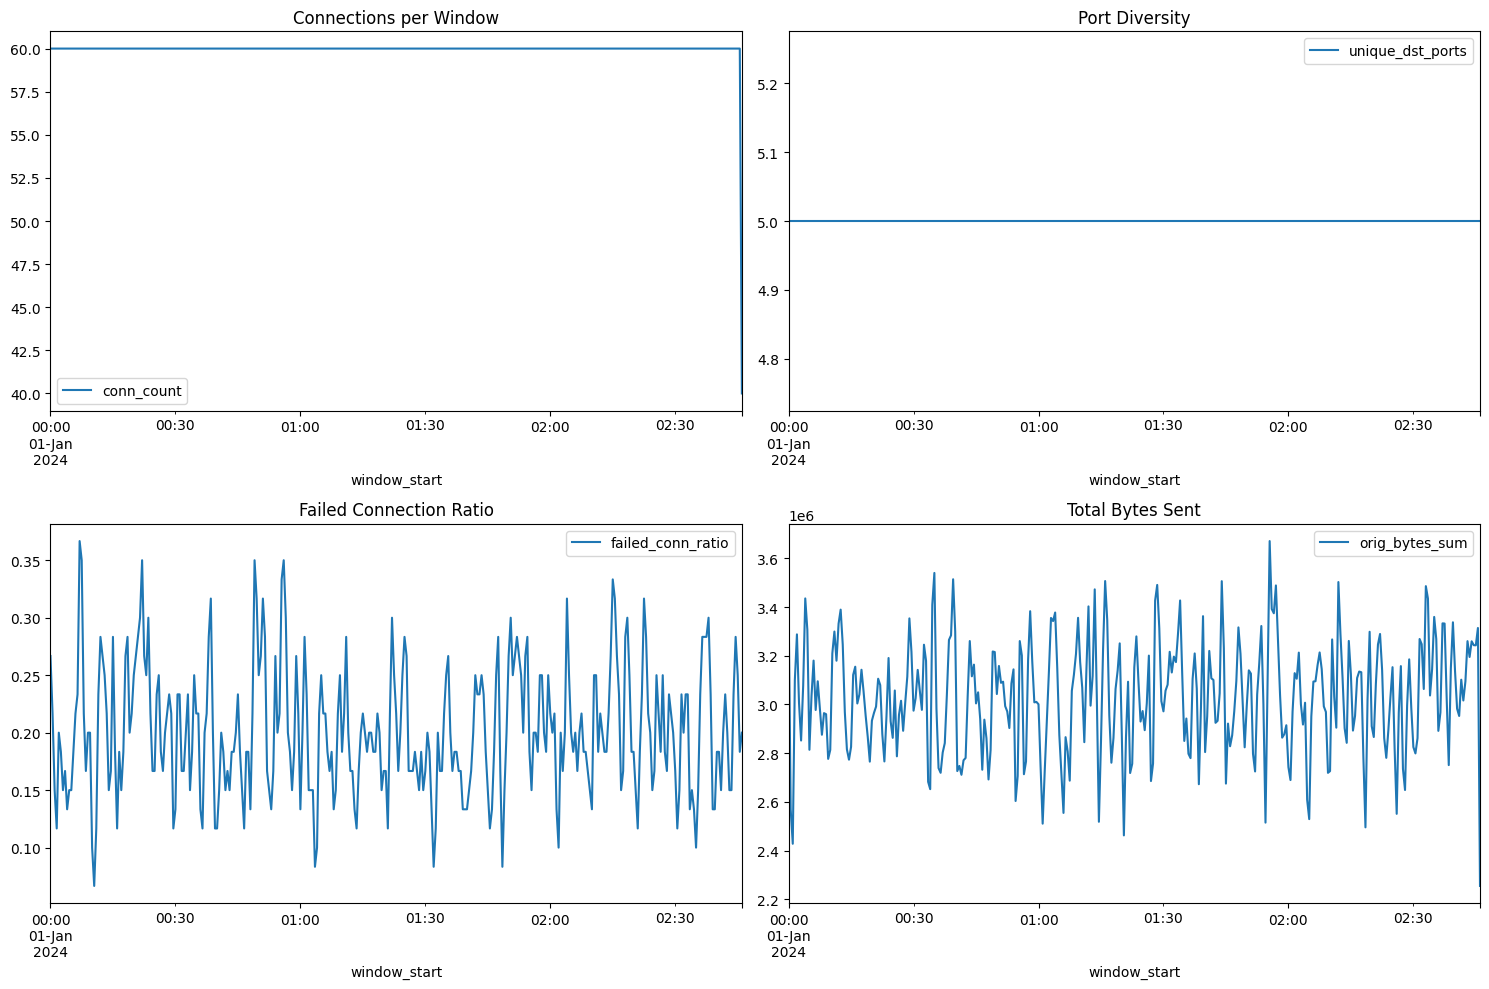

In [ ]:
# Plot key features over time
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df_1min.plot(x="window_start", y="conn_count", ax=axes[0,0], title="Connections per Window")
df_1min.plot(x="window_start", y="unique_dst_ports", ax=axes[0,1], title="Port Diversity")
df_1min.plot(x="window_start", y="failed_conn_ratio", ax=axes[1,0], title="Failed Connection Ratio")
df_1min.plot(x="window_start", y="orig_bytes_sum", ax=axes[1,1], title="Total Bytes Sent")

plt.tight_layout()
plt.savefig("sliding_window_features_timeline.png", dpi=150)
print("Saved: sliding_window_features_timeline.png")
plt.show()

---
## PART 10: Next Steps
Now train your ML models!

In [ ]:
print("""\n" + "="*60)
NEXT STEPS:
="*60)

1. ANOMALY DETECTION (Unsupervised):
   from sklearn.ensemble import IsolationForest
   clf = IsolationForest(contamination=0.1)
   predictions = clf.fit_predict(X_single)

2. CLASSIFICATION (Supervised):
   from sklearn.ensemble import RandomForestClassifier
   from sklearn.model_selection import train_test_split

   X_train, X_test, y_train, y_test = train_test_split(X_single, y_single)
   clf = RandomForestClassifier(n_estimators=100)
   clf.fit(X_train, y_train)

3. DEEP LEARNING (LSTM for sequence):
   import tensorflow as tf
   # Build LSTM model for time-series analysis

4. COMPARE WINDOW SIZES:
   # Train separate models on each window size
   # Compare which window size detects which attacks best

Choose based on your use case:
  • Port scans → 10s windows
  • C2 beaconing → 1min windows
  • Data exfil → 15min/1hr windows
  • Unknown attacks → Try multi-scale approach
""")